In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

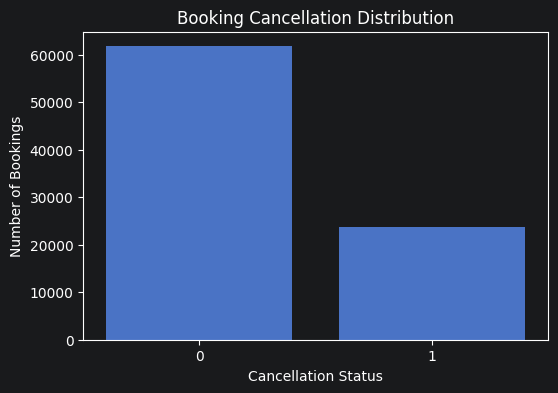

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('cleaned_hotel_bookings.csv')

# Plot
plt.figure(figsize=(6,4))

sns.countplot(x='is_canceled', data=df)

plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancellation Status')
plt.ylabel('Number of Bookings')

plt.show()

In [3]:
cancel_rate = df['is_canceled'].value_counts(normalize=True) * 100

print(cancel_rate)

is_canceled
0    72.155255
1    27.844745
Name: proportion, dtype: float64


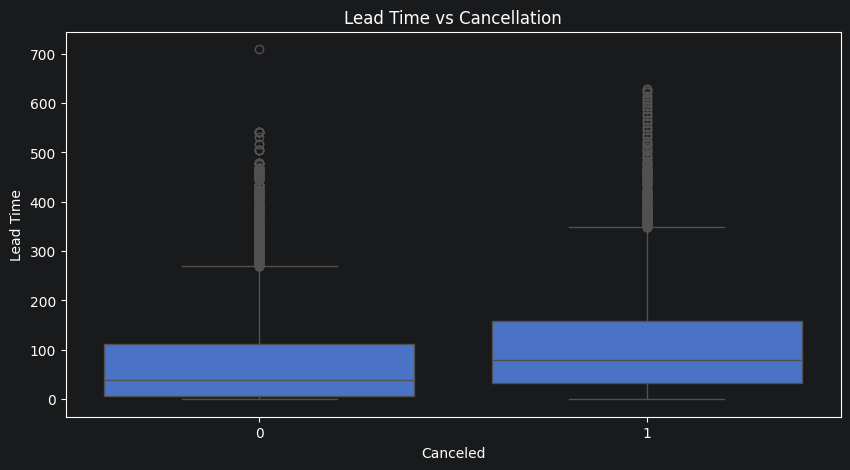

In [4]:
plt.figure(figsize=(10,5))

sns.boxplot(x='is_canceled', y='lead_time', data=df)

plt.title('Lead Time vs Cancellation')
plt.xlabel('Canceled')
plt.ylabel('Lead Time')

plt.show()

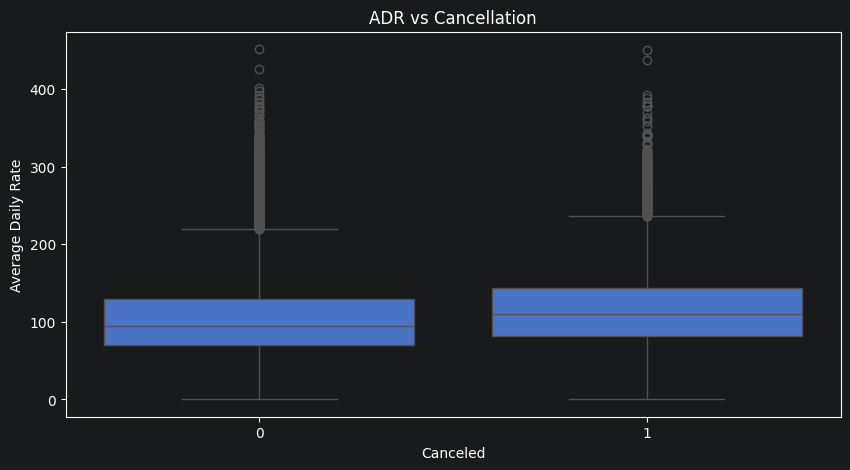

In [5]:
plt.figure(figsize=(10,5))

sns.boxplot(x='is_canceled', y='adr', data=df)

plt.title('ADR vs Cancellation')
plt.xlabel('Canceled')
plt.ylabel('Average Daily Rate')

plt.show()

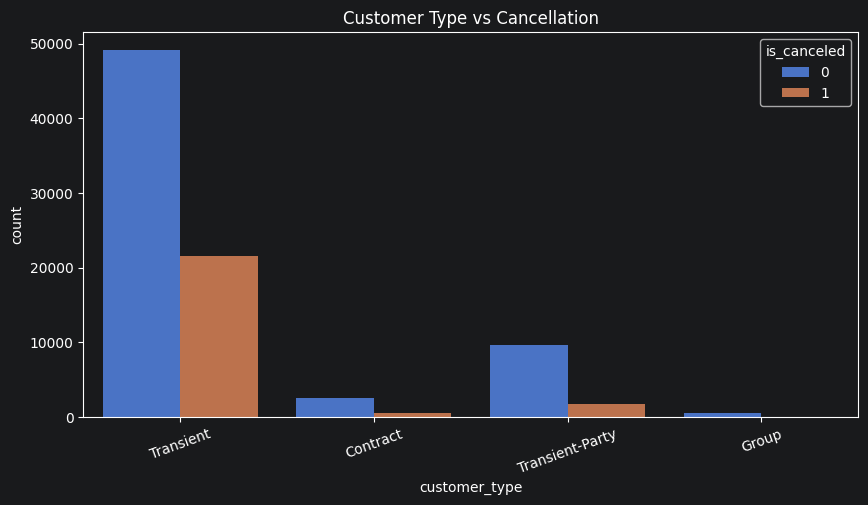

In [6]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='customer_type',
    hue='is_canceled',
    data=df
)

plt.title('Customer Type vs Cancellation')

plt.xticks(rotation=20)

plt.show()

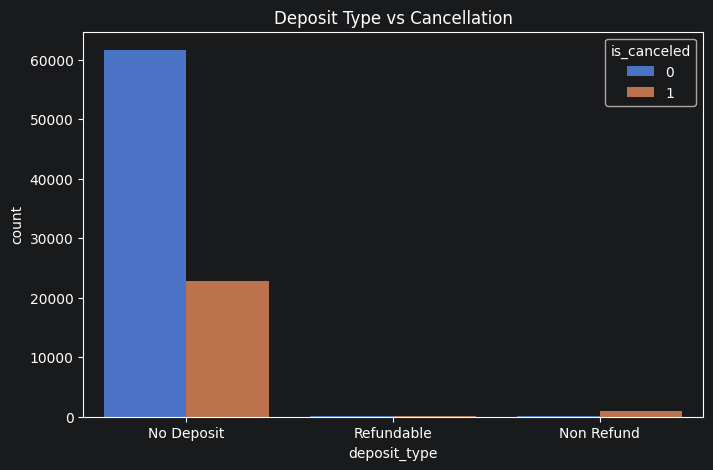

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='deposit_type',
    hue='is_canceled',
    data=df
)

plt.title('Deposit Type vs Cancellation')

plt.show()

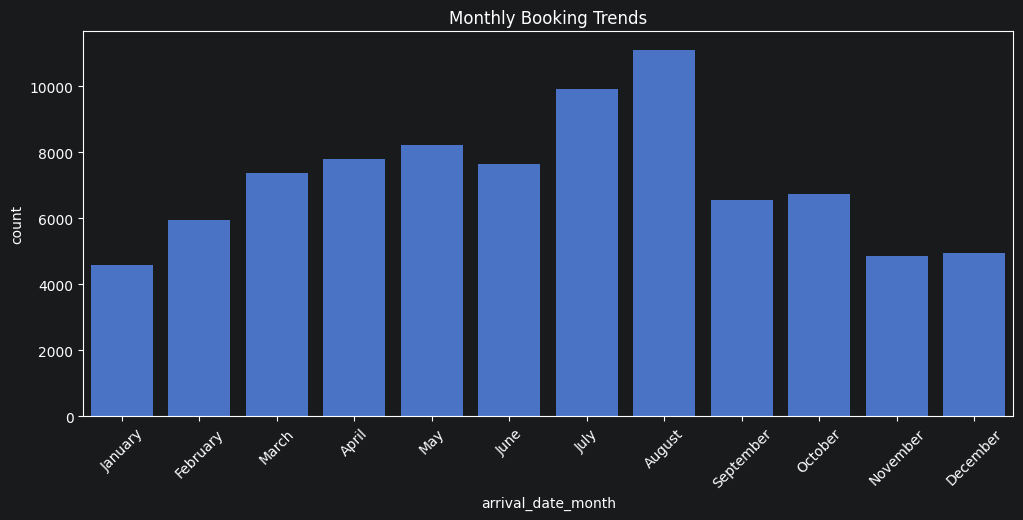

In [8]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

plt.figure(figsize=(12,5))

sns.countplot(
    x='arrival_date_month',
    data=df,
    order=month_order
)

plt.title('Monthly Booking Trends')

plt.xticks(rotation=45)

plt.show()

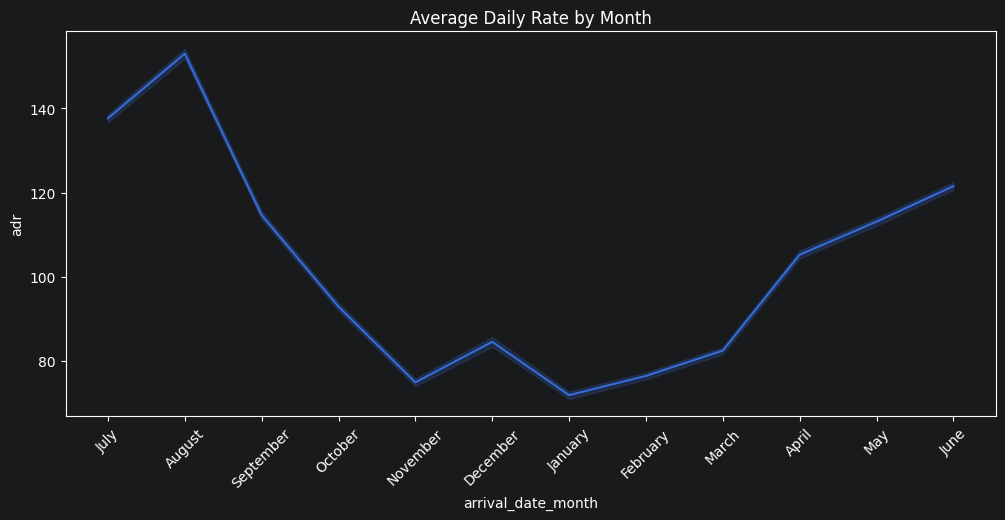

In [10]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x='arrival_date_month',
    y='adr',
    data=df,
    estimator='mean'
)

plt.title('Average Daily Rate by Month')

plt.xticks(rotation=45)

plt.show()

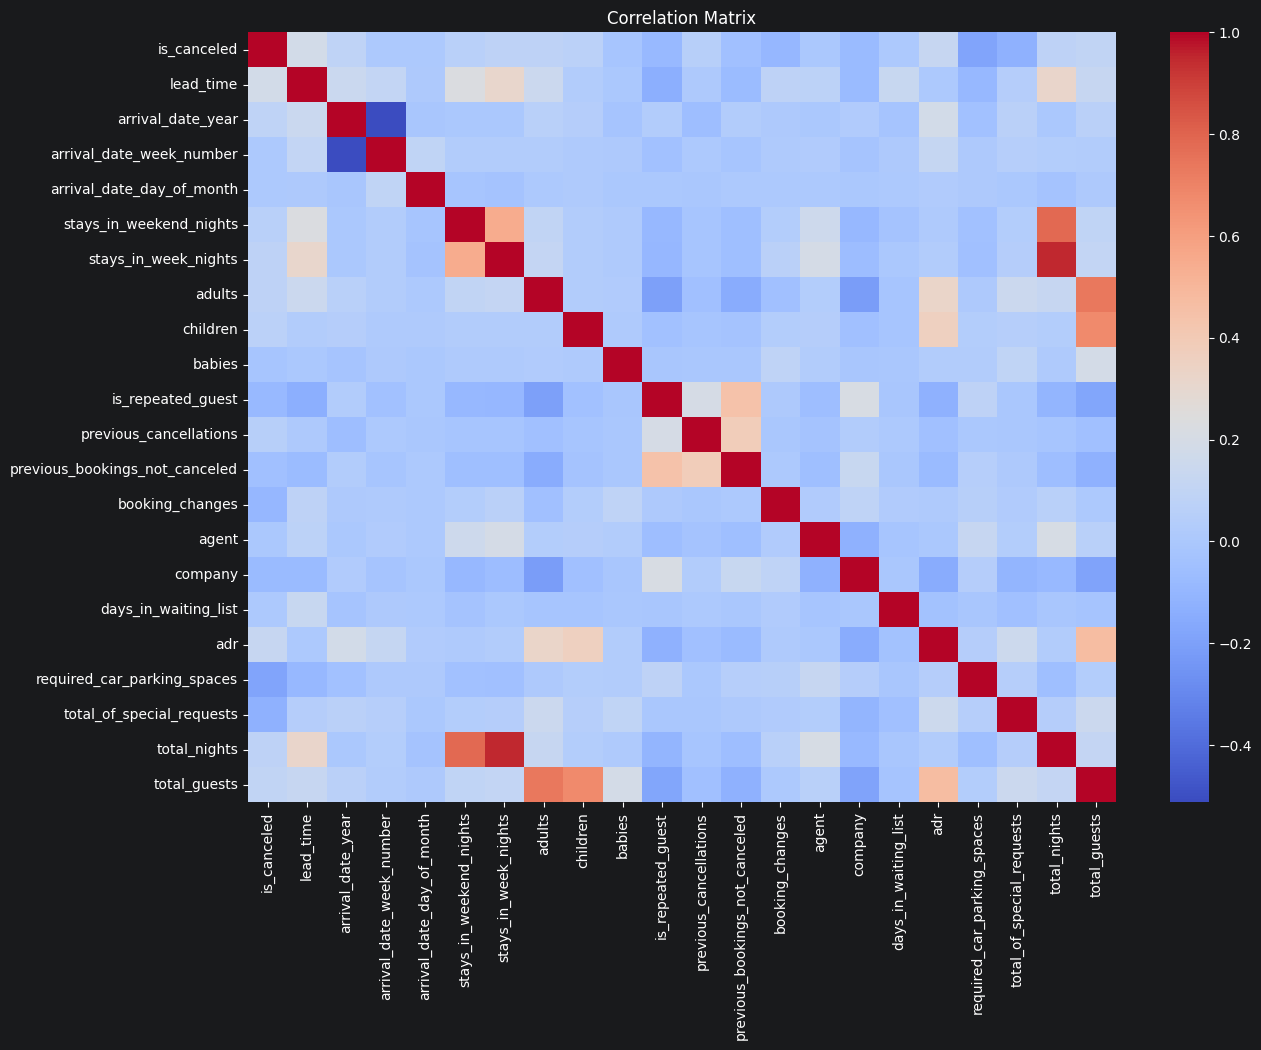

In [11]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

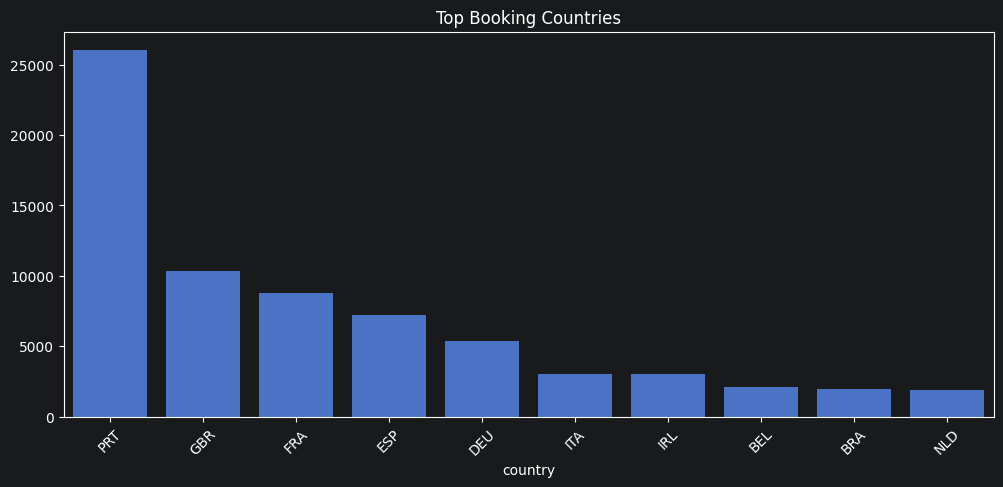

In [12]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title('Top Booking Countries')

plt.xticks(rotation=45)

plt.show()

In [13]:
df_model = df.drop([
    'reservation_status',
    'reservation_status_date'
], axis=1)

In [16]:
X = df_model.drop('is_canceled', axis=1)

y = df_model['is_canceled']

In [17]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\g\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7781930736436372


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86     12376
           1       0.66      0.42      0.51      4747

    accuracy                           0.78     17123
   macro avg       0.73      0.67      0.68     17123
weighted avg       0.76      0.78      0.76     17123



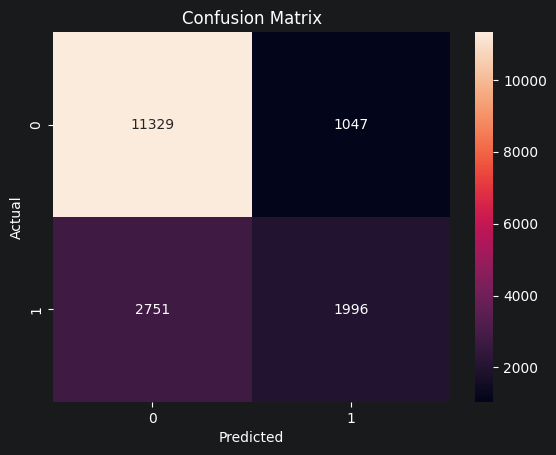

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient
171,country_PRT,1.559342
219,market_segment_Online TA,0.872192
246,customer_type_Transient,0.628721
10,previous_cancellations,0.589087
243,deposit_type_Non Refund,0.436534
23,arrival_date_month_December,0.231825
227,reserved_room_type_D,0.231061
35,meal_SC,0.177995
67,country_CHN,0.166456
87,country_ESP,0.155973


In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
df.to_csv("cleaned_hotel_bookings.csv", index=False)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7781930736436372


In [29]:
from sklearn.metrics import roc_auc_score
roc_score = roc_auc_score(y_test, y_pred)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.6679384329285505


In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance.head(5))

                      Feature  Coefficient
171               country_PRT     1.559342
219  market_segment_Online TA     0.872192
246   customer_type_Transient     0.628721
10     previous_cancellations     0.589087
243   deposit_type_Non Refund     0.436534


In [31]:
print(importance.tail(5))

                          Feature  Coefficient
79                    country_DEU    -0.476105
95                    country_GBR    -0.481007
18      total_of_special_requests    -0.664934
218  market_segment_Offline TA/TO    -0.865340
17    required_car_parking_spaces    -1.375691
